# 📊 Explorando activos financieros con Python y pandas
## Análisis exploratorio de activos de un portafolio

En este laboratorio aprenderás a obtener datos financieros, explorarlos con **pandas**, transformarlos y encontrar información útil para analizar activos.

> **Idea clave:** primero observamos los datos, después calculamos y finalmente interpretamos.


## 🧭 Ruta de aprendizaje

**1. Conectar con los datos** → Yahoo Finance y tickers  
**2. Conocer la información** → DataFrame y estructura  
**3. Mirar antes de calcular** → exploración inicial  
**4. Seguir el comportamiento** → precios y gráficos  
**5. Medir los cambios** → rendimientos  
**6. Describir lo encontrado** → estadísticas  
**7. Comparar para comprender** → varios activos  
**8. Buscar relaciones** → correlación  
**9. Tu análisis** → misión individual


# 1. 🔌 Conectar con los datos

### ¿De dónde obtenemos la información?

Yahoo Finance contiene información histórica de diferentes activos financieros. Para acceder a ella desde Python utilizaremos **yfinance**.

Un **ticker** es el código utilizado para identificar un activo. Por ejemplo: `AAPL`, `MSFT`, `AMZN` o `GOOGL`.


In [1]:
!pip -q install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Nuestro primer activo

Comencemos con Apple. Más adelante cambiaremos el ticker para trabajar con los activos asignados.

In [3]:
ticker = "AAPL"

datos = yf.download(
    ticker,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

datos.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271515,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568916,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139206,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799919,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954910,75.797501,76.110001,74.290001,74.290001,132079200


# 2. 🧩 Conocer la información

Lo que acabamos de obtener es un **DataFrame de pandas**: una estructura de datos organizada en filas y columnas.

Antes de analizar, necesitamos saber qué contiene la tabla y cómo está organizada.


In [4]:
datos.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271515,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568916,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139206,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799919,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954910,75.797501,76.110001,74.290001,74.290001,132079200


In [5]:
datos.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2024-12-24,256.339783,258.200012,258.209991,255.289993,255.490005,23234700
2024-12-26,257.153809,259.019989,260.100006,257.630005,258.190002,27237100
2024-12-27,253.748550,255.589996,258.700012,253.059998,257.829987,42355300
2024-12-30,250.382965,252.199997,253.500000,250.750000,252.229996,35557500
2024-12-31,248.615814,250.419998,253.279999,249.429993,252.440002,39480700


In [6]:
datos.shape

(1258, 6)

In [7]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  1258 non-null   float64
 1   (Close, AAPL)      1258 non-null   float64
 2   (High, AAPL)       1258 non-null   float64
 3   (Low, AAPL)        1258 non-null   float64
 4   (Open, AAPL)       1258 non-null   float64
 5   (Volume, AAPL)     1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB


### 🧠 Piensa

- ¿Qué representa una fila?
- ¿Qué representa una columna?
- ¿Qué información contiene el índice?
- ¿Cuántas observaciones tenemos?

Estas preguntas forman parte del **análisis exploratorio de datos**.

# 3. 🔎 Mirar antes de calcular

Una exploración inicial nos ayuda a detectar características, diferencias o posibles problemas antes de comenzar a realizar cálculos.

In [8]:
datos.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.247344,154.108800,155.660348,152.379123,153.951948,9.057103e+07
std,41.815934,41.520877,41.654310,41.305929,41.466618,5.324438e+07
min,54.117039,56.092499,57.125000,53.152500,57.020000,2.323470e+07
25%,126.170311,129.624996,130.755005,127.505001,129.017506,5.546825e+07
50%,149.839401,152.805000,154.570000,150.825005,152.575005,7.628335e+07
75%,175.750458,178.850006,180.160000,177.115005,178.500004,1.077425e+08
max,257.153809,259.019989,260.100006,257.630005,258.190002,4.265100e+08


In [9]:
datos.isna().sum()

,,0
Price,Ticker,
Adj Close,AAPL,0
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


### 🧠 Interpreta

No basta con ejecutar `describe()`. Observa los resultados y piensa: ¿qué nos permite conocer cada medida sobre los datos?

# 4. 📈 Seguir el comportamiento

Comencemos observando el precio de cierre. Una gráfica puede ayudarnos a identificar tendencias y cambios que serían difíciles de observar en una tabla.

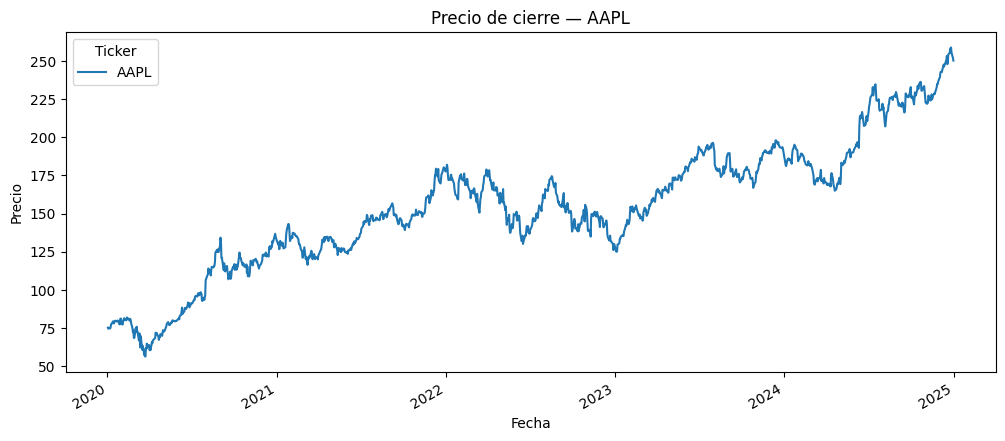

In [10]:
cierre = datos["Close"]

cierre.plot(figsize=(12, 5))
plt.title(f"Precio de cierre — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

### 👀 Observa

Describe brevemente lo que encuentras:

- ¿Se observan períodos de crecimiento o disminución?
- ¿Hay cambios especialmente fuertes?
- ¿El comportamiento parece estable durante todo el período?


# 5. 🔄 Medir los cambios

Comparar solamente precios puede ser insuficiente porque los activos pueden comenzar con valores muy diferentes.

Una alternativa es estudiar los **rendimientos**, que expresan el cambio de una observación respecto a la anterior.


### Cálculo de Rendimientos Financieros

Existen dos formas principales de calcular los rendimientos financieros: discretos y logarítmicos.

#### 1. Rendimientos Discretos (o Simples)

Los rendimientos discretos representan el cambio porcentual en el precio de un activo entre dos períodos consecutivos. Son intuitivos y fáciles de interpretar, ya que reflejan directamente la ganancia o pérdida en relación con el precio inicial. Son adecuados para el cálculo de rendimientos de un solo período.

La fórmula para el rendimiento discreto $R_t$ en el período $t$ es:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_{t-1}$ es el precio del activo en el tiempo $t-1$.

### Ejemplo de Cálculo de Rendimientos

Consideremos los siguientes precios:
*   Precio Anterior ($P_{t-1}$): **100**
*   Precio Actual ($P_t$): **110**

#### 1. Cálculo del Rendimiento Discreto

Utilizando la fórmula:

$$\Large R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{110 - 100}{100} = \frac{10}{100} = 0.10$$

El rendimiento discreto es **0.10** o **10%**.


In [11]:
rendimiento = cierre.pct_change()
rendimiento.head()

Ticker,AAPL
Date,
2020-01-02,NaN
2020-01-03,-0.009722
2020-01-06,0.007968
2020-01-07,-0.004703
2020-01-08,0.016086


El primer valor aparece como `NaN` porque no existe una observación anterior con la cual compararlo.


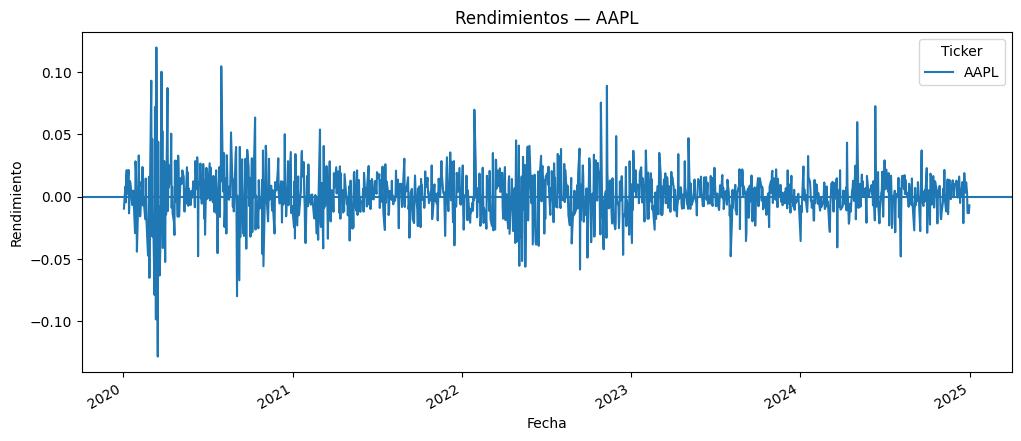

In [12]:
rendimiento.plot(figsize=(12, 5))

plt.axhline(0)
plt.title(f"Rendimientos — {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")
plt.show()

# 6. 📐 Describir lo encontrado

Ahora podemos utilizar las estadísticas descriptivas para conocer mejor la distribución de los rendimientos.

In [13]:
rendimiento.describe()

Ticker,AAPL
count,1257.000000
mean,0.001157
std,0.019957
min,-0.128647
25%,-0.008425
50%,0.001172
75%,0.011989
max,0.119808


### Interpretación de las Estadísticas Descriptivas de Rendimientos

Al analizar la tabla de estadísticas descriptivas para los rendimientos, observamos lo siguiente:

*   **Promedio (Mean):** El promedio de los rendimientos es cercano a cero (aproximadamente 0.1157%). Esto sugiere que, a lo largo del periodo analizado, el rendimiento diario promedio del activo ha sido muy bajo, lo cual es común en series de rendimientos diarios que no muestran una tendencia marcada a largo plazo.

*   **Desviación Estándar (Std):** La desviación estándar es de aproximadamente 1.99%. Esta medida nos indica la dispersión o volatilidad de los rendimientos diarios. Un valor del 2% diario significa que, en promedio, los rendimientos suelen desviarse en un 2% (ya sea al alza o a la baja) de la media. En el contexto financiero, una mayor desviación estándar implica una mayor volatilidad y, por ende, un mayor riesgo.

*   **Mínimo (Min):** El rendimiento mínimo observado es de aproximadamente -12.86%. Esto representa la mayor pérdida porcentual experimentada por el activo en un solo día durante el periodo. Si se hubieran invertido 100 pesos, una pérdida del 12.86% implicaría que el valor de la inversión se reduciría a 87.14 pesos en ese día.

*   **Máximo (Max):** El rendimiento máximo observado es de aproximadamente 11.98%. Esta es la mayor ganancia porcentual en un solo día. Es notable que la máxima pérdida (-12.86%) es ligeramente superior a la máxima ganancia (11.98%), lo que podría indicar una asimetría en los movimientos extremos del activo, con pérdidas más severas en ciertos días.

*   **Percentil 25% (Q1):** El primer cuartil es de -0.84%. Esto significa que el 25% de los días, el rendimiento del activo fue igual o inferior a -0.84%, lo que implica una pérdida para el 25% de las observaciones.

*   **Percentil 50% (Mediana):** La mediana (percentil 50%) es de aproximadamente 0.1172%. Esto indica que el 50% de los rendimientos fueron iguales o inferiores a este valor, y el otro 50% fueron iguales o superiores. Al ser cercano a cero y ligeramente positivo, refuerza la idea de que los rendimientos oscilan alrededor de cero.

*   **Percentil 75% (Q3):** El tercer cuartil es de 1.19%. Esto significa que el 75% de los días, el rendimiento del activo fue igual o inferior a 1.19%, o dicho de otra forma, el 25% de los días la rentabilidad fue superior a 1.19%.

**Ausencia de tendencia y oscilación alrededor de cero:** Esto es típico en las series de rendimientos de activos. A diferencia de los precios, que suelen mostrar tendencias alcistas o bajistas a largo plazo, los rendimientos diarios (o periódicos) tienden a fluctuar en torno a su promedio (que a menudo es cercano a cero). Esto indica que, en el corto plazo, los movimientos positivos y negativos se compensan, sin una dirección clara y sostenida.

**Dispersión alrededor de cero y su variabilidad (Volatilidad)**: Has identificado correctamente que la dispersión de los rendimientos alrededor de cero no es constante. Esta dispersión se mide con la desviación estándar, y en el ámbito financiero se conoce como volatilidad. Una mayor dispersión (picos más altos o valles más profundos) significa mayor volatilidad, lo que implica que el precio del activo está experimentando cambios más grandes en un corto período de tiempo. Los periodos de "alta dispersión" se correlacionan con alta volatilidad (mayor riesgo), mientras que los de "baja dispersión" indican baja volatilidad (menor riesgo).

**Rangos de máximos y mínimos (Variabilidad Extrema):** La observación de que los rendimientos máximos superan el 10% y los mínimos caen por debajo del -10% es crucial. Esto te da una idea del rango extremo de movimientos que el activo ha experimentado en un solo día. Rendimientos tan altos o tan bajos en un solo día son eventos significativos que reflejan la magnitud de los shocks o noticias que afectaron al activo en esos momentos.

# Percentiles extremos


In [14]:
print("Percentil 1:", rendimiento.quantile(0.01))
print("Percentil 5:", rendimiento.quantile(0.05))

Percentil 1: Ticker
AAPL   -0.050317
Name: 0.01, dtype: float64
Percentil 5: Ticker
AAPL   -0.030125
Name: 0.05, dtype: float64


## Interpretación de Percentiles como Pérdida Máxima Esperada (VaR)

Los percentiles 1 y 5 de los rendimientos son a menudo interpretados en el contexto de **Valor en Riesgo (VaR)**, una medida clave en finanzas para cuantificar la pérdida potencial de una inversión.

*   El **percentil 1** de aproximadamente -0.050317 (-5.03%) significa que existe un **1% de probabilidad** de que el activo experimente una pérdida de 5.03% o más de su valor en un día determinado, bajo condiciones normales de mercado. Esto se puede entender como la **máxima pérdida esperada** que el activo podría sufrir con un nivel de confianza del 99% (es decir, hay solo un 1% de posibilidades de que la pérdida real sea mayor).

*   El **percentil 5** de aproximadamente -0.030125 (-3.01%) significa que existe un **5% de probabilidad** de que el activo experimente una pérdida de 3.01% o más de su valor en un día determinado. Esto se interpreta como la **máxima pérdida esperada** con un nivel de confianza del 95% (hay un 5% de posibilidades de que la pérdida real sea mayor).

En resumen, estos valores proporcionan una estimación de las pérdidas extremas que un inversor podría enfrentar con este activo en un día, junto con la probabilidad de que ocurran.

In [15]:
print("Promedio:", rendimiento.mean())
print("Desviación estándar:", rendimiento.std())
print("Mínimo:", rendimiento.min())
print("Máximo:", rendimiento.max())

Promedio: Ticker
AAPL    0.001157
dtype: float64
Desviación estándar: Ticker
AAPL    0.019957
dtype: float64
Mínimo: Ticker
AAPL   -0.128647
dtype: float64
Máximo: Ticker
AAPL    0.119808
dtype: float64


### 🧠 Interpreta

¿Qué nos dice el promedio? ¿Qué información aporta la desviación estándar? ¿Qué representan los valores mínimo y máximo?

Recuerda: **una estadística tiene sentido cuando podemos explicar qué significa en el contexto financiero.**

# 7. ⚖️ Comparar para comprender

Ahora incorporaremos varios activos. La comparación nos permitirá observar diferencias en su comportamiento.

In [16]:
activos = ["AAPL", "MSFT", "AMZN"]

datos = yf.download(
    activos,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

precios = datos["Close"]
precios.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-02,75.087502,94.900497,160.619995
2020-01-03,74.357498,93.748497,158.619995
2020-01-06,74.949997,95.143997,159.029999
2020-01-07,74.597504,95.343002,157.580002
2020-01-08,75.797501,94.598503,160.089996


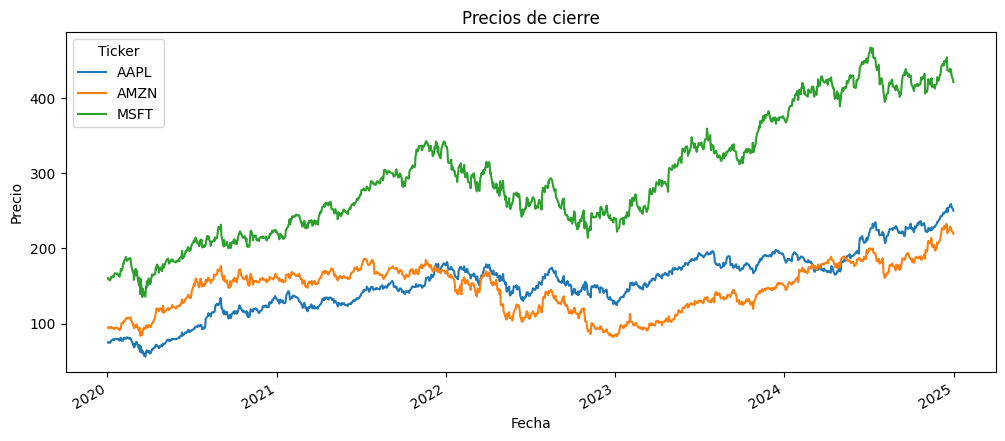

In [17]:
precios.plot(figsize=(12, 5))

plt.title("Precios de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

Los precios pueden tener escalas diferentes. Para comparar su evolución desde un mismo punto de referencia podemos construir un índice base 100.

### Normalización de Precios (Base 100)

Para comparar la evolución de diferentes activos financieros, es útil **normalizar sus precios a una base común**, como 100. Esto permite observar cómo ha crecido o disminuido el valor de cada activo desde un punto de partida equitativo, independientemente de sus precios absolutos iniciales.

La fórmula para normalizar un precio $P_t$ en el tiempo $t$ a una base 100 es:

$$\Large P_{t, \text{normalizado}} = \frac{P_t}{P_0} \times 100$$

Donde:
*   $P_t$ es el precio del activo en el tiempo $t$.
*   $P_0$ es el precio inicial (o precio en el punto de partida) del activo.

#### Ejemplo:

Supongamos que tenemos los siguientes precios para un activo en tres días:

*   Día 1 ($P_0$): **75.00**
*   Día 2 ($P_1$): **74.35**
*   Día 3 ($P_2$): **74.95**

Aplicando la fórmula de normalización:

*   **Día 1:** $\frac{75.00}{75.00} \times 100 = 100$
*   **Día 2:** $\frac{74.35}{75.00} \times 100 \approx 99.13$
*   **Día 3:** $\frac{74.95}{75.00} \times 100 \approx 99.93$

Estos valores normalizados nos permiten ver el cambio porcentual relativo de cada día respecto al día inicial (base 100).

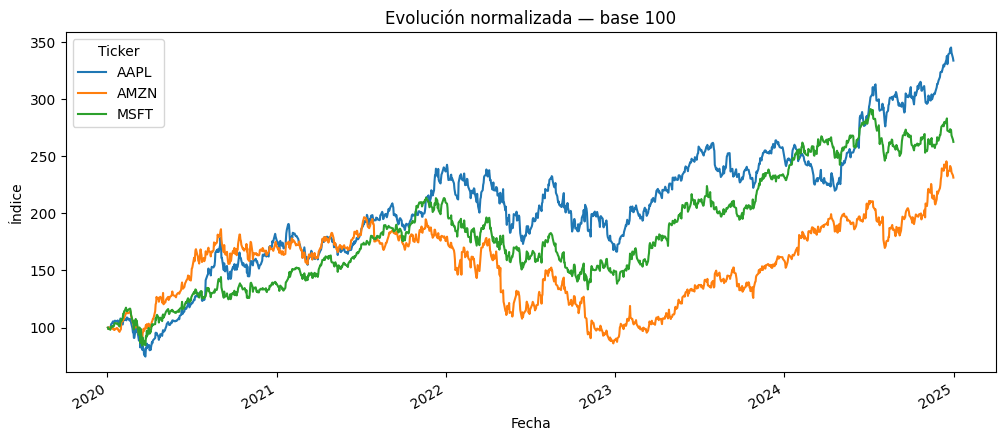

In [18]:
precios_normalizados = precios / precios.iloc[0] * 100

precios_normalizados.plot(figsize=(12, 5))
plt.title("Evolución normalizada — base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.show()

# 8. 🔗 Buscar relaciones

En un portafolio no solo importa cómo se comporta cada activo individualmente. También interesa saber cómo se relacionan entre sí.

Primero calculamos los rendimientos de todos los activos.

In [19]:
rendimientos = precios.pct_change()
rendimientos.head()

Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,-0.009722,-0.012139,-0.012452
2020-01-06,0.007968,0.014886,0.002585
2020-01-07,-0.004703,0.002092,-0.009118
2020-01-08,0.016086,-0.007809,0.015928


In [20]:
correlacion = rendimientos.corr()
correlacion

Ticker,AAPL,AMZN,MSFT
Ticker,,,
AAPL,1.000000,0.591883,0.748121
AMZN,0.591883,1.000000,0.678666
MSFT,0.748121,0.678666,1.000000


### Análisis Financiero de la Matriz de Correlación

La matriz de correlación de los rendimientos es una herramienta fundamental en finanzas para entender la relación entre los movimientos de diferentes activos y es clave para la **diversificación de carteras**.

*   **Correlación Positiva (cercana a +1):** Indica que los rendimientos de los activos tienden a moverse en la misma dirección. Si el rendimiento de un activo sube, es muy probable que el del otro también lo haga, y viceversa. En nuestra matriz, podemos observar una fuerte correlación positiva entre **AAPL y MSFT (0.748)**. Esto significa que si las acciones de Apple suben, las de Microsoft probablemente también lo harán, y si bajan, las de Microsoft también tenderán a bajar. Una correlación alta reduce los beneficios de la diversificación, ya que los activos no actúan como "amortiguadores" el uno del otro en momentos de caída.

*   **Correlación Negativa (cercana a -1):** Sugiere que los rendimientos de los activos tienden a moverse en direcciones opuestas. Si un activo sube, el otro tiende a bajar, y viceversa. Este tipo de correlación es muy deseable para la diversificación, ya que ayuda a mitigar el riesgo de la cartera. En nuestra matriz, no observamos correlaciones negativas fuertes, lo cual es común entre acciones del mismo sector o mercado.

*   **Correlación Cero (cercana a 0):** Implica que no hay una relación lineal predecible entre los movimientos de los rendimientos de los activos. Su comportamiento es independiente el uno del otro. Aunque no reduce el riesgo tan eficazmente como una correlación negativa, sigue siendo beneficioso para la diversificación en comparación con una correlación positiva alta.

#### Implicaciones para la Diversificación:

Para construir un portafolio robusto y diversificado, se busca incluir activos con **baja o negativa correlación**. Esto se debe a que, si un activo experimenta una caída, es probable que otro activo con baja o negativa correlación no caiga (o incluso suba), compensando así parte de la pérdida. Los activos en nuestra matriz muestran correlaciones positivas entre sí, lo que sugiere que son algo dependientes. Por ejemplo, **AAPL** y **AMZN** tienen una correlación de **0.592**, y **AMZN** y **MSFT** de **0.679**. Esto indica que, aunque no se mueven en perfecta sintonía, sus rendimientos sí comparten una tendencia común.

Para mejorar la diversificación, un inversor podría considerar añadir activos de diferentes sectores, geografías o tipos (por ejemplo, bonos, materias primas) que históricamente muestren una correlación más baja o negativa con los activos tecnológicos actuales.

### ¿Cómo podemos leer la correlación?

- Cerca de **1**: los movimientos tienden a ser similares.
- Cerca de **0**: la relación lineal es débil.
- Cerca de **-1**: los movimientos tienden a ser opuestos.

### 💭 Pregunta

Si dos activos presentan una correlación elevada, ¿qué podría significar esto al pensar en diversificación?

# 9. 🚀 Tu análisis

Ahora repite el proceso con los **activos que te fueron asignados**.

Tu análisis debe seguir esta secuencia:

**Obtener → Conocer → Explorar → Transformar → Describir → Comparar → Relacionar → Interpretar**

### Tu misión

1. Obtén los datos históricos desde Yahoo Finance.
2. Explora la estructura del DataFrame.
3. Revisa los datos y los valores faltantes.
4. Observa el comportamiento de los precios.
5. Calcula los rendimientos.
6. Describe los rendimientos con estadísticas.
7. Compara visualmente los activos.
8. Explora la correlación.
9. Escribe una conclusión sustentada en los resultados.

> **Pregunta final:** ¿Qué diferencias encontraste entre los activos y qué información consideras importante conocer antes de incorporarlos a un portafolio?


Punto # 1


In [24]:
tickers = "IBM","WFC","CVX","JNJ","WMT","CAT"

datos = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

datos.head()

[*********************100%***********************]  6 of 6 completed


Price        Adj Close                                               \
Ticker             CAT        CVX        IBM         JNJ        WFC   
Date                                                                  
2020-01-02  132.067871  90.393707  98.017044  121.338516  45.306549   
2020-01-03  130.234207  90.081024  97.235352  119.933693  45.028389   
2020-01-06  130.146454  89.775818  97.061638  119.784088  44.758656   
2020-01-07  128.426865  88.629440  97.126778  120.515564  44.387775   
2020-01-08  129.567383  87.617043  97.937447  120.499001  44.522640   

Price                       Close                                      ...  \
Ticker            WMT         CAT         CVX         IBM         JNJ  ...   
Date                                                                   ...   
2020-01-02  36.203285  150.529999  121.430000  129.464630  145.970001  ...   
2020-01-03  35.883686  148.440002  121.010002  128.432129  144.279999  ...   
2020-01-06  35.810635  148.339996  120.599998  128.202682  144.100006  ...   
2020-01-07  35.478859  146.380005  119.059998  128.288712  144.979996  ...   
2020-01-08  35.357101  147.679993  117.699997  129.359467  144.960007  ...   

Price             Open                                     Volume           \
Ticker             IBM         JNJ        WFC        WMT      CAT      CVX   
Date                                                                         
2020-01-02  129.063095  145.869995  53.849998  39.619999  3311900  5205000   
2020-01-03  127.695984  143.500000  53.110001  39.423332  3100600  6360900   
2020-01-06  127.552582  144.000000  52.740002  39.133331  2549600  9953000   
2020-01-07  127.810707  144.009995  53.049999  39.086666  2841900  7856900   
2020-01-08  128.594650  144.869995  52.840000  38.766666  2153200  7295900   

Price                                             
Ticker          IBM      JNJ       WFC       WMT  
Date                                              
2020-01-02  3293436  5777000  16803100  20294700  
2020-01-03  2482890  5752400  15608800  16197600  
2020-01-06  2537073  7731300  13200300  19336500  
2020-01-07  3232977  7382900  13278600  20540700  
2020-01-08  4545916  6605800  16585600  17627400  

[5 rows x 36 columns]

Punto # 2


In [25]:
datos.head()


Price        Adj Close                                               \
Ticker             CAT        CVX        IBM         JNJ        WFC   
Date                                                                  
2020-01-02  132.067871  90.393707  98.017044  121.338516  45.306549   
2020-01-03  130.234207  90.081024  97.235352  119.933693  45.028389   
2020-01-06  130.146454  89.775818  97.061638  119.784088  44.758656   
2020-01-07  128.426865  88.629440  97.126778  120.515564  44.387775   
2020-01-08  129.567383  87.617043  97.937447  120.499001  44.522640   

Price                       Close                                      ...  \
Ticker            WMT         CAT         CVX         IBM         JNJ  ...   
Date                                                                   ...   
2020-01-02  36.203285  150.529999  121.430000  129.464630  145.970001  ...   
2020-01-03  35.883686  148.440002  121.010002  128.432129  144.279999  ...   
2020-01-06  35.810635  148.339996  120.599998  128.202682  144.100006  ...   
2020-01-07  35.478859  146.380005  119.059998  128.288712  144.979996  ...   
2020-01-08  35.357101  147.679993  117.699997  129.359467  144.960007  ...   

Price             Open                                     Volume           \
Ticker             IBM         JNJ        WFC        WMT      CAT      CVX   
Date                                                                         
2020-01-02  129.063095  145.869995  53.849998  39.619999  3311900  5205000   
2020-01-03  127.695984  143.500000  53.110001  39.423332  3100600  6360900   
2020-01-06  127.552582  144.000000  52.740002  39.133331  2549600  9953000   
2020-01-07  127.810707  144.009995  53.049999  39.086666  2841900  7856900   
2020-01-08  128.594650  144.869995  52.840000  38.766666  2153200  7295900   

Price                                             
Ticker          IBM      JNJ       WFC       WMT  
Date                                              
2020-01-02  3293436  5777000  16803100  20294700  
2020-01-03  2482890  5752400  15608800  16197600  
2020-01-06  2537073  7731300  13200300  19336500  
2020-01-07  3232977  7382900  13278600  20540700  
2020-01-08  4545916  6605800  16585600  17627400  

[5 rows x 36 columns]

In [26]:
datos.tail()

Price        Adj Close                                                 \
Ticker             CAT         CVX         IBM         JNJ        WFC   
Date                                                                    
2024-12-24  359.902527  133.733017  214.390503  139.277832  68.932617   
2024-12-26  359.461914  133.863190  214.849075  139.019989  69.096313   
2024-12-27  357.248993  133.881760  212.833267  138.513885  68.470444   
2024-12-30  355.437683  133.017136  210.416214  136.880936  67.796425   
2024-12-31  355.192841  134.662750  210.014984  138.103241  67.632721   

Price                       Close                                      ...  \
Ticker            WMT         CAT         CVX         IBM         JNJ  ...   
Date                                                                   ...   
2024-12-24  91.220375  367.570007  143.839996  224.410004  145.850006  ...   
2024-12-26  91.328644  367.119995  143.979996  224.889999  145.580002  ...   
2024-12-27  90.216446  364.859985  144.000000  222.779999  145.050003  ...   
2024-12-30  89.143608  363.010010  143.070007  220.250000  143.339996  ...   
2024-12-31  88.927071  362.760010  144.839996  219.830002  144.619995  ...   

Price             Open                                     Volume           \
Ticker             IBM         JNJ        WFC        WMT      CAT      CVX   
Date                                                                         
2024-12-24  222.270004  145.000000  70.669998  90.370003   886000  3556100   
2024-12-26  223.309998  145.509995  71.430000  92.540001  1097900  4492600   
2024-12-27  223.139999  144.869995  71.180000  92.129997  1245800  5296500   
2024-12-30  220.539993  144.839996  70.410004  90.730003  1422200  6194800   
2024-12-31  220.720001  143.759995  70.529999  90.570000  1168100  6137800   

Price                                            
Ticker          IBM      JNJ      WFC       WMT  
Date                                             
2024-12-24  1186200  3164100  4442700   8992400  
2024-12-26  3286500  4656300  6964300  10994000  
2024-12-27  1810800  5588300  7219500  11384400  
2024-12-30  2095600  6268700  8443800   9790200  
2024-12-31  2270200  5811400  7031500  11267700  

[5 rows x 36 columns]

In [27]:
datos.shape

(1258, 36)

In [28]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Adj Close, CAT)  1258 non-null   float64
 1   (Adj Close, CVX)  1258 non-null   float64
 2   (Adj Close, IBM)  1258 non-null   float64
 3   (Adj Close, JNJ)  1258 non-null   float64
 4   (Adj Close, WFC)  1258 non-null   float64
 5   (Adj Close, WMT)  1258 non-null   float64
 6   (Close, CAT)      1258 non-null   float64
 7   (Close, CVX)      1258 non-null   float64
 8   (Close, IBM)      1258 non-null   float64
 9   (Close, JNJ)      1258 non-null   float64
 10  (Close, WFC)      1258 non-null   float64
 11  (Close, WMT)      1258 non-null   float64
 12  (High, CAT)       1258 non-null   float64
 13  (High, CVX)       1258 non-null   float64
 14  (High, IBM)       1258 non-null   float64
 15  (High, JNJ)       1258 non-null   float64
 16  (High, WFC)       1258 n

Punto # 3


In [29]:
datos.describe()

Price     Adj Close                                                      \
Ticker          CAT          CVX          IBM          JNJ          WFC   
count   1258.000000  1258.000000  1258.000000  1258.000000  1258.000000   
mean     217.644115   112.912840   124.083602   142.161361    40.344009   
std       74.916050    32.324524    33.516116    11.699457    11.175749   
min       81.150078    40.833660    69.310829    92.974976    18.450832   
25%      172.204620    82.071005   100.977335   137.368977    35.427406   
50%      202.647064   129.682579   113.202110   144.402229    40.134975   
75%      257.622719   140.293213   132.161377   150.119007    45.374584   
max      408.183929   161.055786   227.411957   163.873474    74.478813   

Price                      Close                                         ...  \
Ticker          WMT          CAT          CVX          IBM          JNJ  ...   
count   1258.000000  1258.000000  1258.000000  1258.000000  1258.000000  ...   
mean      49.160430   231.009372   132.828140   142.914556   159.904491  ...   
std       11.903438    73.067940    32.500621    29.278197    11.014087  ...   
min       31.671019    91.849998    54.220001    90.602295   111.139999  ...   
25%       42.674695   184.659996   102.609999   123.371193   151.232498  ...   
50%       45.392349   217.879997   145.005005   134.440002   160.684998  ...   
75%       51.264304   267.962502   159.595005   147.402504   167.210007  ...   
max       93.984581   416.880005   188.050003   238.039993   186.009995  ...   

Price          Open                                               Volume  \
Ticker          IBM          JNJ          WFC          WMT           CAT   
count   1258.000000  1258.000000  1258.000000  1258.000000  1.258000e+03   
mean     142.839956   159.895421    44.358386    51.538487  3.222038e+06   
std       29.212189    10.983733    11.175102    11.418621  1.526550e+06   
min       90.439774   117.000000    21.049999    35.066666  5.857000e+05   
25%      123.415392   151.357506    39.272500    45.418334  2.254675e+06   
50%      134.515778   160.870003    44.790001    48.184999  2.811200e+06   
75%      147.432503   167.100006    49.945001    53.054167  3.745350e+06   
max      238.000000   185.100006    77.690002    95.680000  1.209330e+07   

Price                                                                         
Ticker           CVX           IBM           JNJ           WFC           WMT  
count   1.258000e+03  1.258000e+03  1.258000e+03  1.258000e+03  1.258000e+03  
mean    9.924249e+06  5.010390e+06  8.157561e+06  2.606633e+07  2.240747e+07  
std     4.841161e+06  3.068824e+06  7.819653e+06  1.461386e+07  1.265154e+07  
min     2.796400e+06  1.186200e+06  2.114900e+06  4.442700e+06  6.287500e+06  
25%     7.005925e+06  3.401195e+06  5.671375e+06  1.592152e+07  1.498395e+07  
50%     8.817800e+06  4.271948e+06  6.821100e+06  2.146860e+07  1.916415e+07  
75%     1.104450e+07  5.616307e+06  8.487225e+06  3.220862e+07  2.528768e+07  
max     5.723100e+07  3.981442e+07  1.513195e+08  1.189526e+08  1.329402e+08  

[8 rows x 36 columns]

In [30]:
datos.isna().sum()

Price      Ticker
Adj Close  CAT       0
           CVX       0
           IBM       0
           JNJ       0
           WFC       0
           WMT       0
Close      CAT       0
           CVX       0
           IBM       0
           JNJ       0
           WFC       0
           WMT       0
High       CAT       0
           CVX       0
           IBM       0
           JNJ       0
           WFC       0
           WMT       0
Low        CAT       0
           CVX       0
           IBM       0
           JNJ       0
           WFC       0
           WMT       0
Open       CAT       0
           CVX       0
           IBM       0
           JNJ       0
           WFC       0
           WMT       0
Volume     CAT       0
           CVX       0
           IBM       0
           JNJ       0
           WFC       0
           WMT       0
dtype: int64

Punto # 4


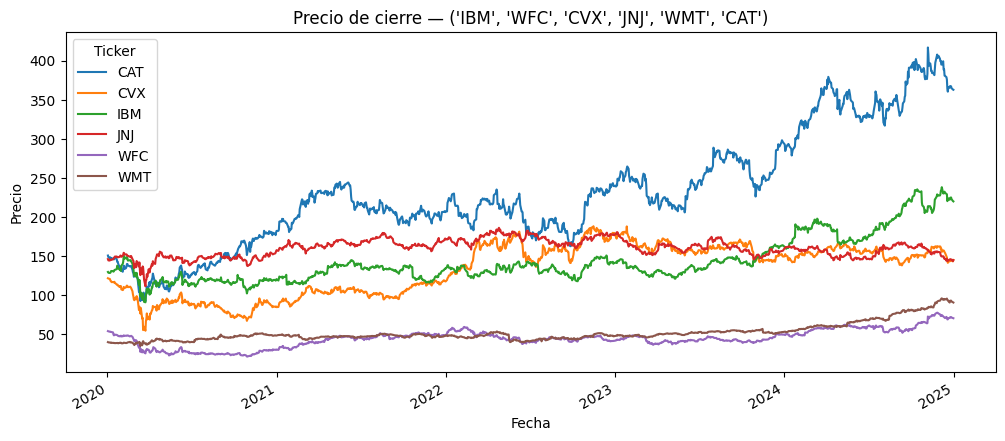

In [31]:
cierre = datos["Close"]

cierre.plot(figsize=(12, 5))
plt.title(f"Precio de cierre — {tickers}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

Punto # 5

In [32]:
rendimiento = cierre.pct_change()
rendimiento.head()

Ticker,CAT,CVX,IBM,JNJ,WFC,WMT
Date,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.013884,-0.003459,-0.007975,-0.011578,-0.006140,-0.008828
2020-01-06,-0.000674,-0.003388,-0.001787,-0.001248,-0.005990,-0.002036
2020-01-07,-0.013213,-0.012769,0.000671,0.006107,-0.008286,-0.009265
2020-01-08,0.008881,-0.011423,0.008346,-0.000138,0.003038,-0.003432


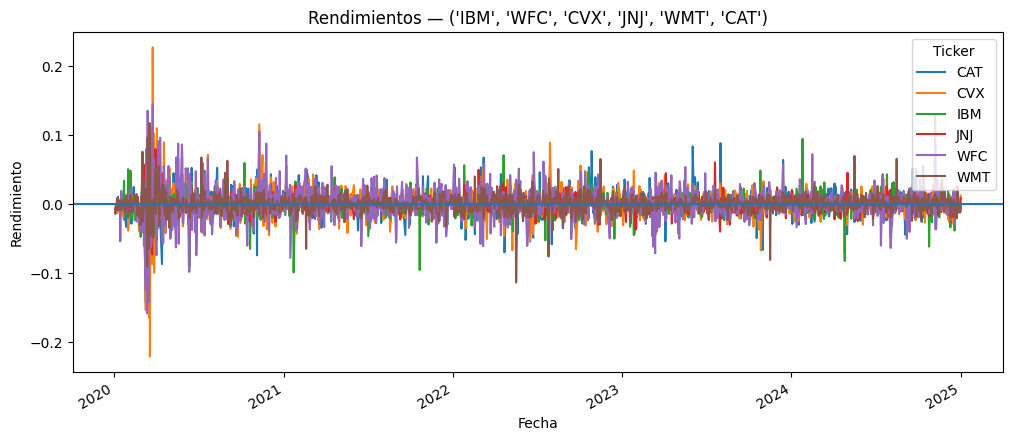

In [33]:
rendimiento.plot(figsize=(12, 5))

plt.axhline(0)
plt.title(f"Rendimientos — {tickers}")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento")
plt.show()

Punto # 6

In [34]:
rendimiento.describe()

Ticker,CAT,CVX,IBM,JNJ,WFC,WMT
count,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000
mean,0.000910,0.000395,0.000565,0.000069,0.000517,0.000757
std,0.020466,0.022452,0.016921,0.012421,0.024663,0.014236
min,-0.142822,-0.221248,-0.128507,-0.072984,-0.158676,-0.113757
25%,-0.009864,-0.009259,-0.006803,-0.005977,-0.011526,-0.005869
50%,0.000880,0.000739,0.000976,0.000062,0.000350,0.000663
75%,0.011762,0.009763,0.008195,0.005922,0.012157,0.007320
max,0.103321,0.227407,0.113010,0.079977,0.145347,0.117085


In [35]:
print("Percentil 1:", rendimiento.quantile(0.01))
print("Percentil 3:", rendimiento.quantile(0.03))
print("Percentil 6:", rendimiento.quantile(0.06))

Percentil 1: Ticker
CAT   -0.054438
CVX   -0.049669
IBM   -0.049647
JNJ   -0.032448
WFC   -0.062254
WMT   -0.032172
Name: 0.01, dtype: float64
Percentil 3: Ticker
CAT   -0.038333
CVX   -0.037142
IBM   -0.029192
JNJ   -0.021642
WFC   -0.046730
WMT   -0.022145
Name: 0.03, dtype: float64
Percentil 6: Ticker
CAT   -0.027737
CVX   -0.026995
IBM   -0.020425
JNJ   -0.016015
WFC   -0.033156
WMT   -0.017359
Name: 0.06, dtype: float64


In [36]:
print("Promedio:", rendimiento.mean())
print("Desviación estándar:", rendimiento.std())
print("Mínimo:", rendimiento.min())
print("Máximo:", rendimiento.max())

Promedio: Ticker
CAT    0.000910
CVX    0.000395
IBM    0.000565
JNJ    0.000069
WFC    0.000517
WMT    0.000757
dtype: float64
Desviación estándar: Ticker
CAT    0.020466
CVX    0.022452
IBM    0.016921
JNJ    0.012421
WFC    0.024663
WMT    0.014236
dtype: float64
Mínimo: Ticker
CAT   -0.142822
CVX   -0.221248
IBM   -0.128507
JNJ   -0.072984
WFC   -0.158676
WMT   -0.113757
dtype: float64
Máximo: Ticker
CAT    0.103321
CVX    0.227407
IBM    0.113010
JNJ    0.079977
WFC    0.145347
WMT    0.117085
dtype: float64


Punto # 7

In [37]:
activos = ["IBM","WFC","CVX","JNJ","WMT","CAT"]

datos = yf.download(
    activos,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

precios = datos["Close"]
precios.head()

[*********************100%***********************]  6 of 6 completed


Ticker,CAT,CVX,IBM,JNJ,WFC,WMT
Date,,,,,,
2020-01-02,150.529999,121.430000,129.464630,145.970001,53.750000,39.646667
2020-01-03,148.440002,121.010002,128.432129,144.279999,53.419998,39.296665
2020-01-06,148.339996,120.599998,128.202682,144.100006,53.099998,39.216667
2020-01-07,146.380005,119.059998,128.288712,144.979996,52.660000,38.853333
2020-01-08,147.679993,117.699997,129.359467,144.960007,52.820000,38.720001


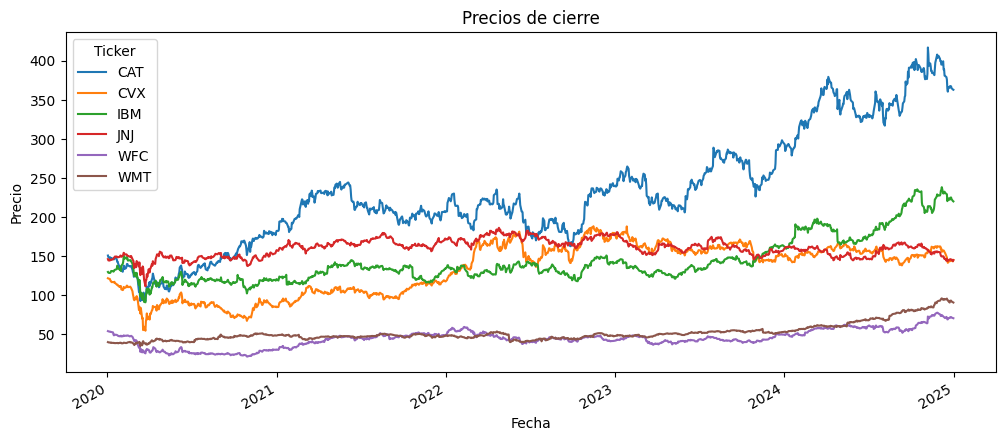

In [38]:
precios.plot(figsize=(12, 5))

plt.title("Precios de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

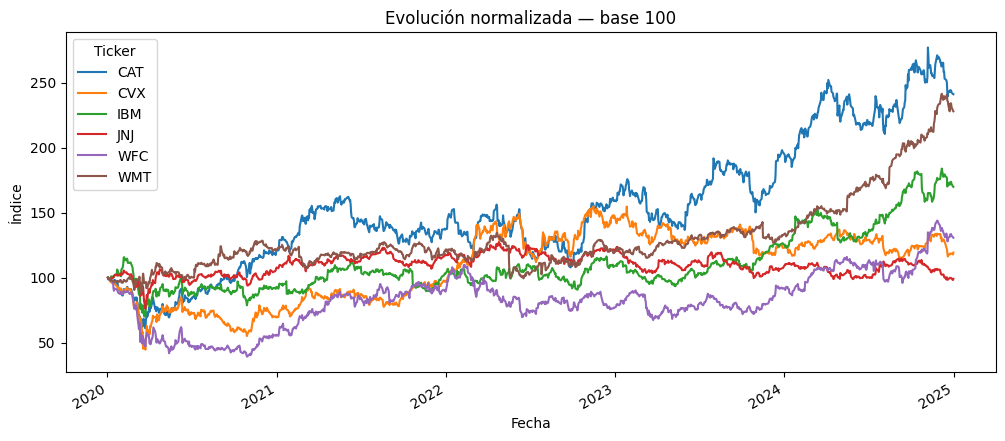

In [39]:
precios_normalizados = precios / precios.iloc[0] * 100

precios_normalizados.plot(figsize=(12, 5))
plt.title("Evolución normalizada — base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.show()


Punto # 8

In [40]:
rendimientos = precios.pct_change()
rendimientos.head()

Ticker,CAT,CVX,IBM,JNJ,WFC,WMT
Date,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.013884,-0.003459,-0.007975,-0.011578,-0.006140,-0.008828
2020-01-06,-0.000674,-0.003388,-0.001787,-0.001248,-0.005990,-0.002036
2020-01-07,-0.013213,-0.012769,0.000671,0.006107,-0.008286,-0.009265
2020-01-08,0.008881,-0.011423,0.008346,-0.000138,0.003038,-0.003432


In [41]:
correlacion = rendimientos.corr()
correlacion

Ticker,CAT,CVX,IBM,JNJ,WFC,WMT
Ticker,,,,,,
CAT,1.000000,0.592509,0.528386,0.343856,0.584835,0.220454
CVX,0.592509,1.000000,0.485164,0.370744,0.559803,0.188403
IBM,0.528386,0.485164,1.000000,0.478278,0.526196,0.306616
JNJ,0.343856,0.370744,0.478278,1.000000,0.358097,0.403611
WFC,0.584835,0.559803,0.526196,0.358097,1.000000,0.227475
WMT,0.220454,0.188403,0.306616,0.403611,0.227475,1.000000


Punto # 9

A partir del análisis realizado sobre las acciones CAT, CVX, IBM, JNJ, WFC y WMT.

En cuanto a la relación entre los activos, las correlaciones fueron principalmente positivas y moderadas. Esto indica que varios de ellos tienden a moverse en la misma dirección.

Encontramos que el que mas destaca es CAT con mejor rendimiento diario es el tercer activo mas volatil y ademas es el activo que mas crecio entre 2020 y 2025 con un crecuimiento de mas del doble de su valor.

En CVX encontramos que es el segundo activo mas volatil y que tuvo el quinto puesto de mejor renidmiento diario y demostrando un crecimiento en el periodo de menos del 20%

IBM es la tercera con mejor rendimiento diario y es la 4 en mas volatilidad del portafolio tambien demostrando un crecimiento de casi el doble.

JNJ es la menos volatil de todas y la que menos rendimiento diario tiene y entre el periodo 2020 y 2025 no crecio nada antes perdio casi un 1%

WFC es la segunda con mejor rendimiento diario y es la mas volatil y tambien crecio entre el periodo analizado un 40% mas

WMT es la segunda con mayor rendimiento diario y la quinta menos volatil y subio casi el doble de su valor

Por lo tanto seria en el siguiente orden del mejor al peor activo:

1- CAT
2- WMT
3- IBM
4- WFC
5- CVX
6- JNJ

mi decision seria reducirlo a 5 activos sacando JNJ ya que no representa crecimiento


## 🎫 Salida de aprendizaje

Completa estas tres frases en una celda de texto:

- **Encontré que…**
- **La información que más me ayudó a comparar los activos fue…**
- **Antes de construir un portafolio, considero importante revisar…**
